# Section 1: Project Setup

## Introduction

Before performing diagnostic quality assessment, it is essential to establish a reproducible and organized project environment. This section initializes the project by importing the required libraries, configuring project paths, setting random seeds, verifying the dataset structure, and preparing the logging system.

A well-structured setup ensures that every experiment can be reproduced consistently while minimizing errors related to missing files, incorrect paths, or inconsistent execution.

---

## Objectives

- Import all required libraries.
- Configure project directories.
- Enable reproducibility using fixed random seeds.
- Verify the dataset structure.
- Initialize the logging system.
- Display project information.

---

## Expected Output

After completing this section:

- All libraries are successfully imported.
- Random seeds are initialized.
- Dataset directories are verified.
- Output folders are available.
- Logging is initialized.
- The project is ready for diagnostic quality assessment.

In [1]:
# Import standard libraries

import os
import sys
import random
from pathlib import Path

# Import third-party libraries

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

# Ignore unnecessary warnings

import warnings

warnings.filterwarnings("ignore")

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [35]:
from tqdm import tqdm

In [6]:
# Set random seed

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 42


In [7]:
# Add project root to Python path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\Projects\DermaCQI


In [8]:
# Import project configuration

from src.utils.config import *

In [9]:
from src.utils.logger import get_logger

logger = get_logger("Notebook_01")

logger.info("Notebook 1 started successfully.")

2026-07-26 14:59:48,865 | INFO | Notebook_01 | Notebook 1 started successfully.


# Section 2: Dataset Validation

## Introduction

Before performing diagnostic quality assessment, it is essential to verify the integrity of the HAM10000 dataset. This step ensures that the required files and folders exist, images can be accessed, and the metadata file is available for subsequent analysis.

---

## Objectives

- Verify the dataset directory structure.
- Verify the metadata file.
- Count the total number of images.
- Check whether all required resources are available.

---

## Expected Output

A summary confirming that the dataset has been successfully located and is ready for analysis.

In [10]:
from pathlib import Path

print("Dataset Directory")
print(DATASET_DIR)

print("\nMetadata File")
print(HAM10000_METADATA)

Dataset Directory
D:\Projects\DermaCQI\datasets

Metadata File
D:\Projects\DermaCQI\datasets\HAM10000_metadata.csv


In [11]:
print("=" * 60)
print("DATASET VALIDATION")
print("=" * 60)

required_items = {
    "Metadata File": HAM10000_METADATA,
    "Images Part 1": IMAGES_PART1,
    "Images Part 2": IMAGES_PART2,
}

for name, path in required_items.items():
    if path.exists():
        print(f"✓ {name}")
    else:
        print(f"✗ {name}")

print("\nDataset validation completed.")

DATASET VALIDATION
✓ Metadata File
✓ Images Part 1
✓ Images Part 2

Dataset validation completed.


In [12]:
image_files = []

image_files.extend(IMAGES_PART1.glob("*.jpg"))
image_files.extend(IMAGES_PART2.glob("*.jpg"))

total_images = len(image_files)

print("=" * 60)
print("IMAGE COUNT")
print("=" * 60)
print(f"Total Images : {total_images:,}")

IMAGE COUNT
Total Images : 10,015


In [13]:
metadata = pd.read_csv(HAM10000_METADATA)

print("=" * 60)
print("METADATA INFORMATION")
print("=" * 60)

print(f"Rows    : {metadata.shape[0]}")
print(f"Columns : {metadata.shape[1]}")

METADATA INFORMATION
Rows    : 10015
Columns : 7


In [14]:
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [15]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [16]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

metadata.isnull().sum()

MISSING VALUES


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [17]:
duplicate_rows = metadata.duplicated().sum()

print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

print(f"Duplicate Rows : {duplicate_rows}")

DUPLICATE RECORDS
Duplicate Rows : 0


In [18]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Total Images    : {total_images:,}")
print(f"Metadata Records: {len(metadata):,}")

if total_images == len(metadata):
    print("\n✅ Dataset validation completed successfully.")
else:
    print("\n⚠️ Image count and metadata records do not match.")

DATASET SUMMARY
Total Images    : 10,015
Metadata Records: 10,015

✅ Dataset validation completed successfully.


# Section 3: Dataset Exploration

## Introduction

---

Dataset exploration provides an overview of the HAM10000 dataset by examining its structure, class distribution, patient demographics, and lesion localization. This analysis helps understand the dataset characteristics before performing diagnostic image quality assessment.

## Objectives

---

- Explore the metadata structure.
- Analyze disease class distribution.
- Examine patient age and gender distribution.
- Analyze lesion localization.
- Identify potential class imbalance.

## Expected Output

---

A comprehensive overview of the HAM10000 dataset through statistical summaries and visualizations, providing insights into disease distribution and patient demographics.

In [19]:
# Dataset overview

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Number of Samples : {len(metadata):,}")
print(f"Number of Features: {metadata.shape[1]}")

print("\nColumns")

for column in metadata.columns:
    print(f"- {column}")

DATASET OVERVIEW
Number of Samples : 10,015
Number of Features: 7

Columns
- lesion_id
- image_id
- dx
- dx_type
- age
- sex
- localization


In [20]:
# Metadata information

metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [21]:
# Disease class distribution

class_distribution = metadata["dx"].value_counts().sort_values(ascending=False)

print("=" * 60)
print("DISEASE CLASS DISTRIBUTION")
print("=" * 60)

print(class_distribution)

DISEASE CLASS DISTRIBUTION
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


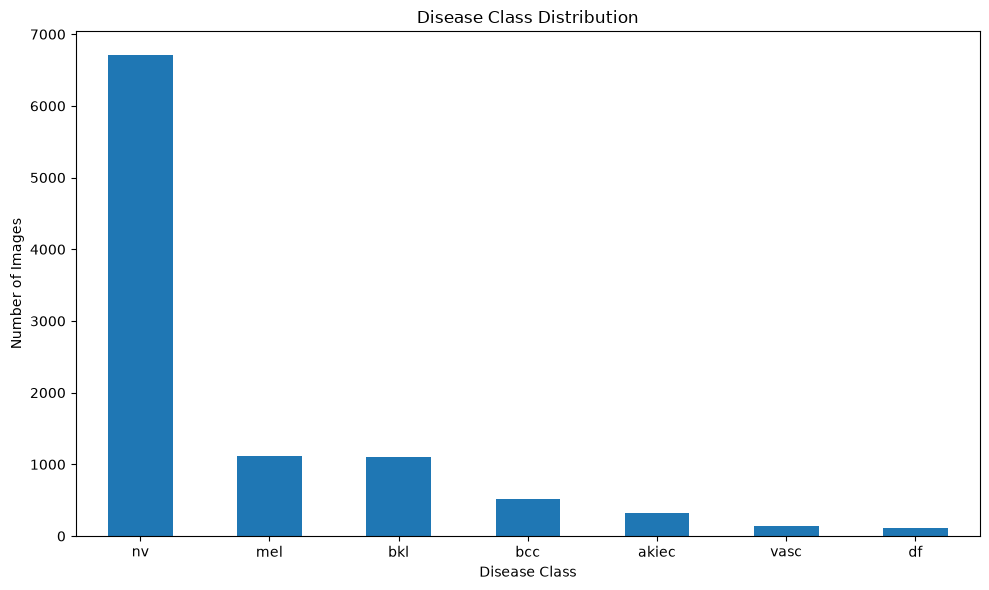

In [22]:
# Disease class visualization

plt.figure(figsize=(10, 6))

class_distribution.plot(kind="bar")

plt.title("Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
# Disease class percentage

class_percentage = (
    metadata["dx"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("=" * 60)
print("CLASS PERCENTAGE")
print("=" * 60)

print(class_percentage)

CLASS PERCENTAGE
dx
nv       66.95
mel      11.11
bkl      10.97
bcc       5.13
akiec     3.27
vasc      1.42
df        1.15
Name: proportion, dtype: float64


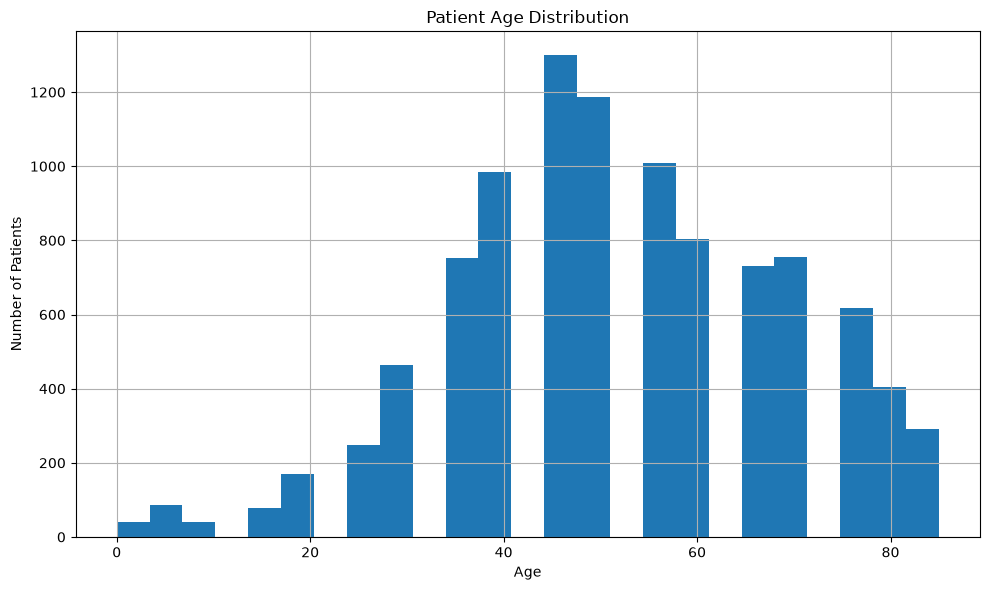

In [24]:
# Age distribution

plt.figure(figsize=(10, 6))

metadata["age"].dropna().hist(bins=25)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [25]:
# Age statistics

print("=" * 60)
print("AGE STATISTICS")
print("=" * 60)

print(metadata["age"].describe())

AGE STATISTICS
count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64


In [26]:
# Gender distribution

gender_distribution = metadata["sex"].value_counts()

print("=" * 60)
print("GENDER DISTRIBUTION")
print("=" * 60)

print(gender_distribution)

GENDER DISTRIBUTION
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64


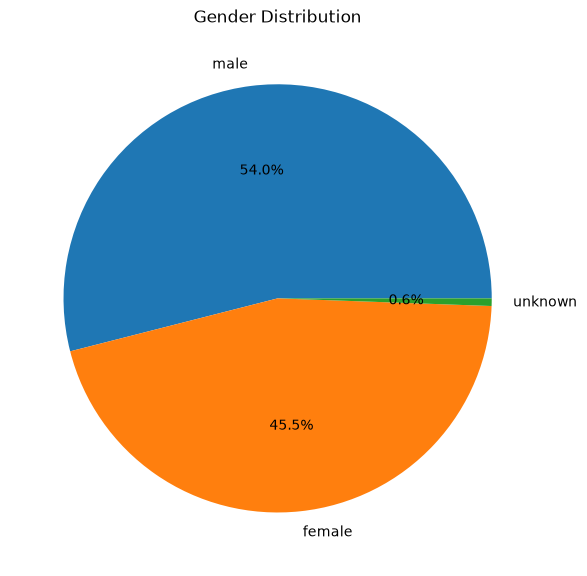

In [27]:
# Gender visualization

plt.figure(figsize=(6, 6))

gender_distribution.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Gender Distribution")

plt.tight_layout()
plt.show()

In [28]:
# Lesion localization

localization = metadata["localization"].value_counts()

print("=" * 60)
print("LESION LOCALIZATION")
print("=" * 60)

print(localization)

LESION LOCALIZATION
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64


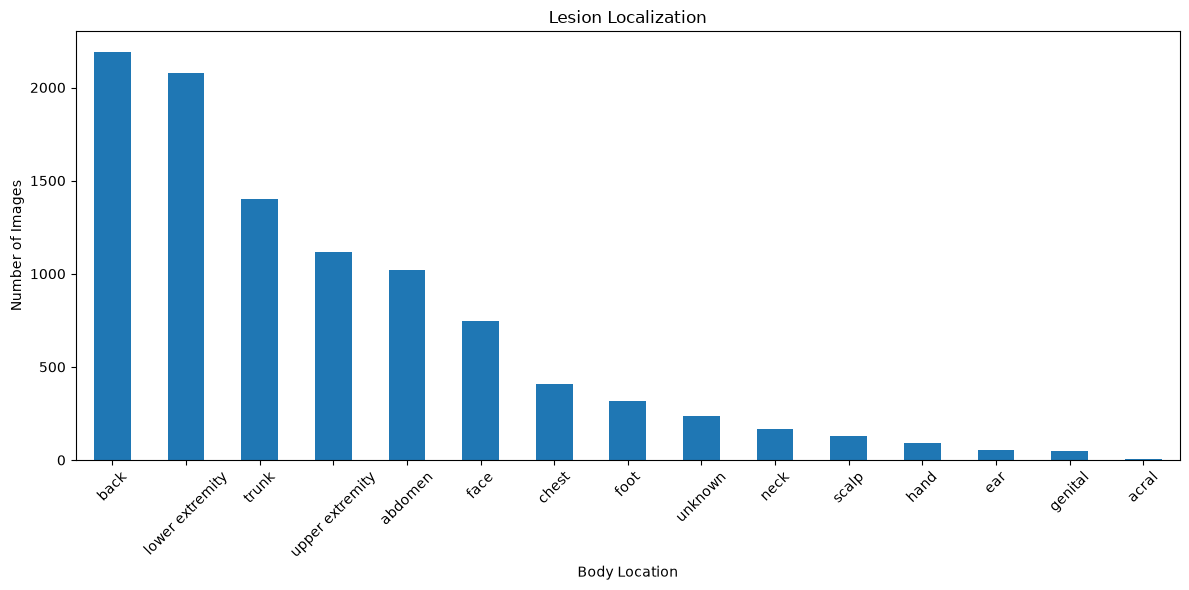

In [29]:
# Lesion localization visualization

plt.figure(figsize=(12, 6))

localization.plot(kind="bar")

plt.title("Lesion Localization")
plt.xlabel("Body Location")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
# Statistical summary

print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

display(metadata.describe(include="all"))

STATISTICAL SUMMARY


,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


In [31]:
# Dataset insights

print("=" * 60)
print("DATASET INSIGHTS")
print("=" * 60)

print(f"Total Images          : {len(metadata):,}")
print(f"Number of Classes     : {metadata['dx'].nunique()}")
print(f"Most Common Class     : {class_distribution.idxmax()}")
print(f"Least Common Class    : {class_distribution.idxmin()}")
print(f"Average Patient Age   : {metadata['age'].mean():.2f} years")
print(f"Male Patients         : {gender_distribution.get('male', 0)}")
print(f"Female Patients       : {gender_distribution.get('female', 0)}")
print(f"Unknown Gender        : {gender_distribution.get('unknown', 0)}")
print(f"Most Common Location  : {localization.idxmax()}")

DATASET INSIGHTS
Total Images          : 10,015
Number of Classes     : 7
Most Common Class     : nv
Least Common Class    : df
Average Patient Age   : 51.86 years
Male Patients         : 5406
Female Patients       : 4552
Unknown Gender        : 57
Most Common Location  : back


# Section 4: Diagnostic Contrast Assessment

## Introduction

---

Image contrast is one of the most important quality indicators in dermoscopic imaging. Low-contrast images can obscure lesion boundaries, reduce texture visibility, and negatively affect automated skin lesion classification. Therefore, contrast assessment is performed before any image enhancement to quantify the visual quality of each image.

## Objectives

---

- Measure the contrast of every dermoscopic image.
- Generate a numerical contrast score for each image.
- Analyze the distribution of contrast scores across the dataset.
- Identify images with extremely low and high contrast.
- Store the computed contrast scores for subsequent Composite Quality Index (CQI) calculation.

## Expected Output

---

- Contrast score for every image in the HAM10000 dataset.
- Statistical summary of contrast quality.
- Contrast distribution visualization.
- Identification of low-contrast and high-contrast images.
- A contrast score column added to the dataset for CQI computation.

In [32]:
# Import library

from skimage import exposure

In [33]:
# Calculate contrast score

def calculate_contrast_score(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    contrast = gray.std()

    return contrast

In [36]:
# Calculate contrast scores

contrast_scores = []

for image_path in tqdm(image_files):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    score = calculate_contrast_score(image)

    contrast_scores.append(score)

100%|██████████| 10015/10015 [02:05<00:00, 79.93it/s]


In [37]:
# Add contrast scores

metadata["contrast_score"] = contrast_scores

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,contrast_score
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,31.016334
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,18.567454
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,49.687620
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,23.000077
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,31.513469


In [38]:
# Contrast statistics

print("=" * 60)
print("CONTRAST STATISTICS")
print("=" * 60)

print(metadata["contrast_score"].describe())

CONTRAST STATISTICS
count    10015.000000
mean        28.037591
std         11.358865
min          5.259409
25%         19.818554
50%         26.041636
75%         34.162134
max         85.487211
Name: contrast_score, dtype: float64


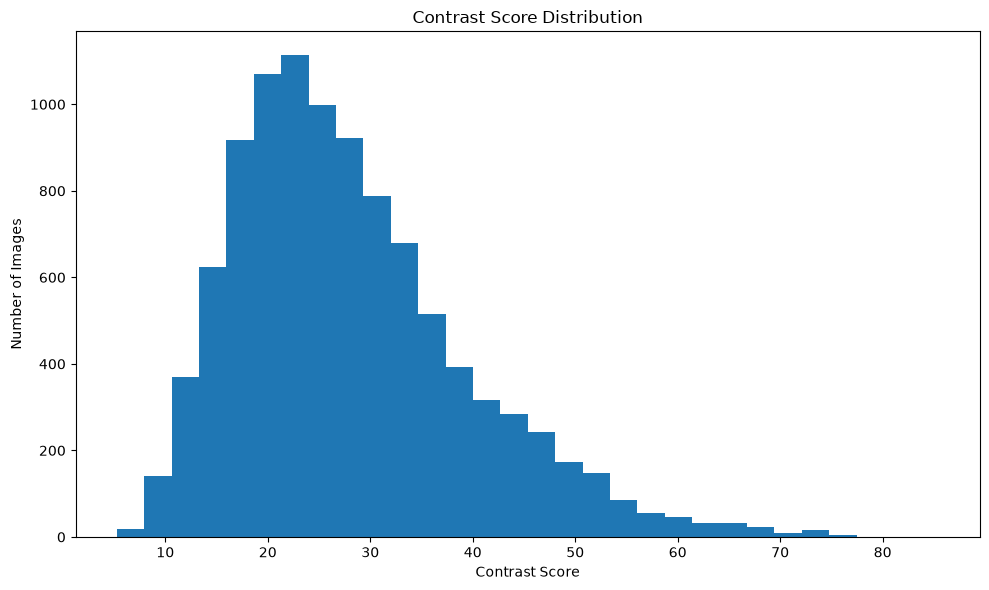

In [39]:
# Contrast distribution

plt.figure(figsize=(10,6))

plt.hist(metadata["contrast_score"], bins=30)

plt.title("Contrast Score Distribution")
plt.xlabel("Contrast Score")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

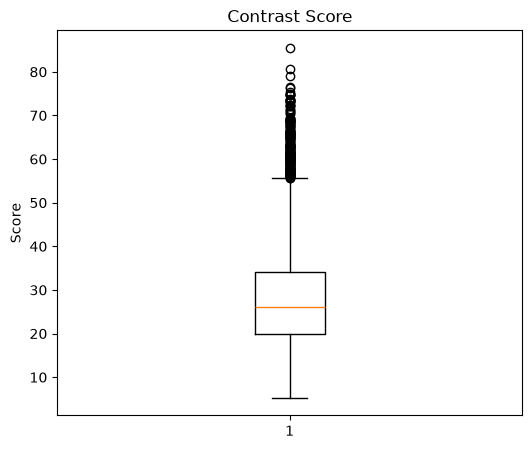

In [40]:
# Contrast box plot

plt.figure(figsize=(6,5))

plt.boxplot(metadata["contrast_score"])

plt.title("Contrast Score")

plt.ylabel("Score")

plt.show()

In [41]:
# Lowest contrast images

lowest_contrast = metadata.nsmallest(5, "contrast_score")

lowest_contrast[["image_id", "dx", "contrast_score"]]

,image_id,dx,contrast_score
7864,ISIC_0033443,nv,5.259409
2875,ISIC_0032030,bcc,5.403519
4844,ISIC_0030987,nv,6.077925
625,ISIC_0031716,bkl,6.270197
6370,ISIC_0026943,nv,6.302554


In [42]:
# Highest contrast images

highest_contrast = metadata.nlargest(5, "contrast_score")

highest_contrast[["image_id", "dx", "contrast_score"]]

,image_id,dx,contrast_score
741,ISIC_0029443,bkl,85.487211
8968,ISIC_0031982,nv,80.616258
9579,ISIC_0033383,nv,78.963520
3509,ISIC_0027591,nv,76.569433
4286,ISIC_0032413,nv,76.273001


In [43]:
# Save contrast scores

metadata.to_csv(
    OUTPUT_DIR / "contrast_scores.csv",
    index=False
)

print("Contrast scores saved successfully.")

Contrast scores saved successfully.


# Section 5: Diagnostic Brightness Assessment

## Introduction

---

Brightness is a critical image quality attribute that influences the visibility of skin lesions and their diagnostic features. Images that are too dark or too bright may conceal important lesion structures, reducing the performance of automated classification systems. Therefore, brightness assessment is performed to quantify the illumination quality of each dermoscopic image.

## Objectives

---

- Measure the brightness of every dermoscopic image.
- Generate a brightness score for each image.
- Analyze the brightness distribution across the dataset.
- Identify underexposed and overexposed images.
- Store the brightness scores for Composite Quality Index (CQI) computation.

## Expected Output

---

- Brightness score for every image.
- Statistical summary of brightness.
- Brightness distribution visualization.
- Identification of low and high brightness images.
- Brightness score added to the metadata.

In [44]:
# Calculate brightness score

def calculate_brightness_score(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    brightness = np.mean(gray)

    return brightness

In [45]:
# Calculate brightness scores

brightness_scores = []

for image_path in tqdm(image_files):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    score = calculate_brightness_score(image)

    brightness_scores.append(score)

100%|██████████| 10015/10015 [00:37<00:00, 265.64it/s]


In [46]:
# Add brightness scores

metadata["brightness_score"] = brightness_scores

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,contrast_score,brightness_score
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,31.016334,146.754770
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,18.567454,152.554907
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,49.687620,153.042381
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,23.000077,134.099256
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,31.513469,153.591919


In [47]:
# Brightness statistics

print("=" * 60)
print("BRIGHTNESS STATISTICS")
print("=" * 60)

print(metadata["brightness_score"].describe())

BRIGHTNESS STATISTICS
count    10015.000000
mean       156.556942
std         19.232437
min         58.222330
25%        143.669411
50%        156.404711
75%        169.474141
max        229.886074
Name: brightness_score, dtype: float64


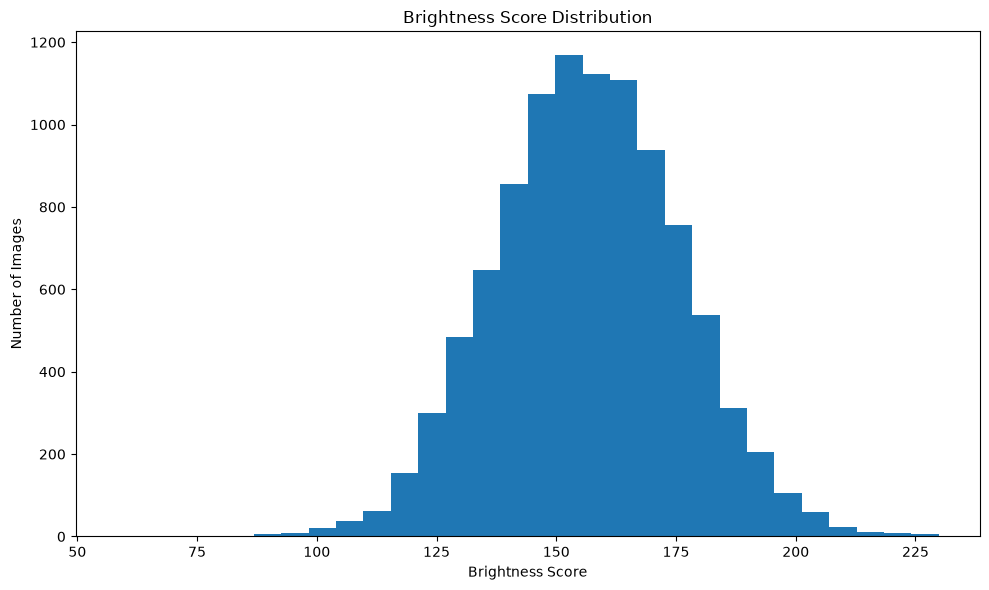

In [48]:
# Brightness distribution

plt.figure(figsize=(10, 6))

plt.hist(metadata["brightness_score"], bins=30)

plt.title("Brightness Score Distribution")
plt.xlabel("Brightness Score")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

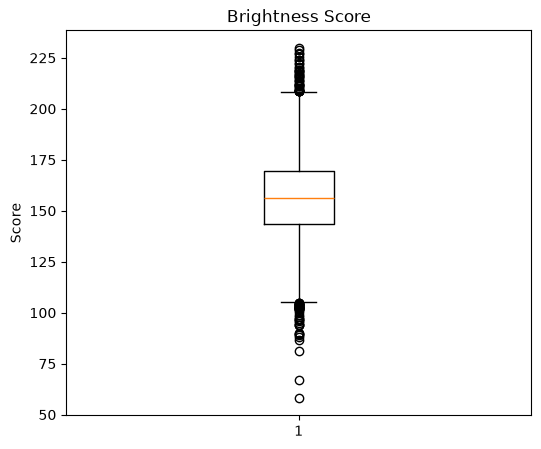

In [49]:
# Brightness box plot

plt.figure(figsize=(6, 5))

plt.boxplot(metadata["brightness_score"])

plt.title("Brightness Score")
plt.ylabel("Score")

plt.show()

In [50]:
# Lowest brightness images

lowest_brightness = metadata.nsmallest(5, "brightness_score")

lowest_brightness[["image_id", "dx", "brightness_score"]]

,image_id,dx,brightness_score
1657,ISIC_0033209,mel,58.222330
815,ISIC_0027608,bkl,66.777281
639,ISIC_0030318,bkl,81.298315
4515,ISIC_0029874,nv,86.759189
7600,ISIC_0033667,nv,88.264474


In [51]:
# Highest brightness images

highest_brightness = metadata.nlargest(5, "brightness_score")

highest_brightness[["image_id", "dx", "brightness_score"]]

,image_id,dx,brightness_score
9491,ISIC_0034018,nv,229.886074
9907,ISIC_0026626,akiec,229.031174
9533,ISIC_0034193,nv,227.154370
5098,ISIC_0031324,nv,227.069219
3804,ISIC_0026129,nv,225.190670


In [52]:
# Save brightness scores

metadata.to_csv(
    OUTPUT_DIR / "brightness_scores.csv",
    index=False
)

print("Brightness scores saved successfully.")

Brightness scores saved successfully.


# Section 6: Diagnostic Blur Assessment

## Introduction

---

Image blur reduces the visibility of lesion boundaries, pigment networks, and other diagnostic structures. Blurred dermoscopic images can significantly decrease the performance of deep learning models. Therefore, blur assessment is performed to quantify image sharpness before enhancement.

## Objectives

---

- Measure the sharpness of every dermoscopic image.
- Generate a blur score for each image.
- Analyze blur distribution across the dataset.
- Identify highly blurred and highly sharp images.
- Store blur scores for Composite Quality Index (CQI) computation.

## Expected Output

---

- Blur score for every image.
- Statistical summary of blur quality.
- Blur distribution visualization.
- Identification of blurred and sharp images.
- Blur score added to the metadata.

In [53]:
# Calculate blur score using Laplacian variance

def calculate_blur_score(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    return blur_score

In [54]:
# Calculate blur scores

blur_scores = []

for image_path in tqdm(image_files):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    score = calculate_blur_score(image)

    blur_scores.append(score)

100%|██████████| 10015/10015 [00:55<00:00, 180.66it/s]


In [55]:
# Add blur scores

metadata["blur_score"] = blur_scores

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,contrast_score,brightness_score,blur_score
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,31.016334,146.754770,43.876503
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,18.567454,152.554907,53.289048
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,49.687620,153.042381,85.947015
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,23.000077,134.099256,30.222626
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,31.513469,153.591919,156.135217


In [56]:
# Blur statistics

print("=" * 60)
print("BLUR STATISTICS")
print("=" * 60)

print(metadata["blur_score"].describe())

BLUR STATISTICS
count    10015.000000
mean        79.234460
std        124.965445
min          7.623581
25%         34.369786
50%         49.244037
75%         89.461601
max       3825.024580
Name: blur_score, dtype: float64


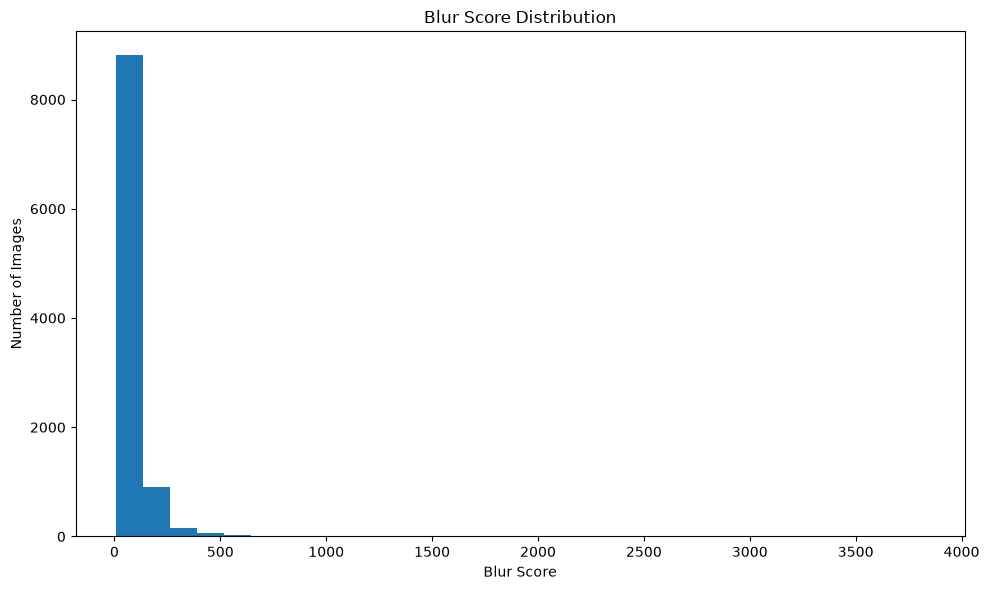

In [57]:
# Blur distribution

plt.figure(figsize=(10, 6))

plt.hist(metadata["blur_score"], bins=30)

plt.title("Blur Score Distribution")
plt.xlabel("Blur Score")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

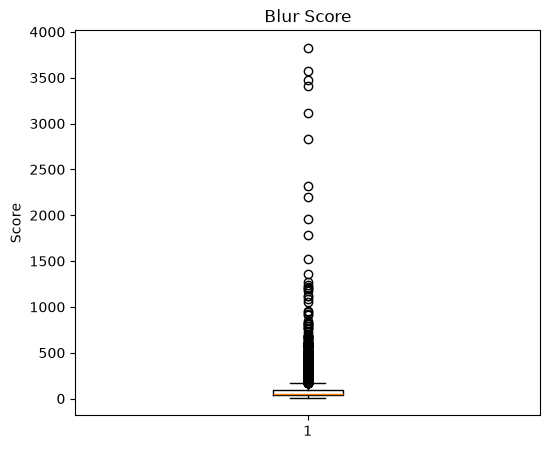

In [58]:
# Blur box plot

plt.figure(figsize=(6, 5))

plt.boxplot(metadata["blur_score"])

plt.title("Blur Score")
plt.ylabel("Score")

plt.show()

In [59]:
# Most blurred images

most_blurred = metadata.nsmallest(5, "blur_score")

most_blurred[["image_id", "dx", "blur_score"]]

,image_id,dx,blur_score
6648,ISIC_0026031,nv,7.623581
1716,ISIC_0032856,mel,7.876364
610,ISIC_0026335,bkl,7.923333
7659,ISIC_0032813,nv,8.353864
4327,ISIC_0027325,nv,8.468672


In [60]:
# Sharpest images

sharpest = metadata.nlargest(5, "blur_score")

sharpest[["image_id", "dx", "blur_score"]]

,image_id,dx,blur_score
7908,ISIC_0033786,nv,3825.024580
6717,ISIC_0029845,nv,3567.801900
3916,ISIC_0029330,nv,3473.190951
3239,ISIC_0030128,nv,3410.912734
6381,ISIC_0027123,nv,3113.461053


In [61]:
# Save blur scores

metadata.to_csv(
    OUTPUT_DIR / "blur_scores.csv",
    index=False
)

print("Blur scores saved successfully.")

Blur scores saved successfully.


# Section 7: Diagnostic Noise Assessment

## Introduction

---

Image noise introduces unwanted pixel variations that can obscure lesion textures, borders, and color patterns. Measuring the amount of noise helps determine the diagnostic quality of dermoscopic images before enhancement and classification.

## Objectives

---

- Estimate the noise level of every dermoscopic image.
- Generate a noise score for each image.
- Analyze the distribution of noise scores.
- Identify images with the highest and lowest noise levels.
- Store the noise scores for Composite Quality Index (CQI) computation.

## Expected Output

---

- Noise score for every image.
- Statistical summary of image noise.
- Noise distribution visualization.
- Identification of noisy and clean images.
- Noise score added to the metadata.

In [62]:
# Calculate noise score

def calculate_noise_score(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    noise = cv2.absdiff(gray, blurred)

    noise_score = np.mean(noise)

    return noise_score

In [63]:
# Calculate noise scores

noise_scores = []

for image_path in tqdm(image_files):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    score = calculate_noise_score(image)

    noise_scores.append(score)

100%|██████████| 10015/10015 [00:39<00:00, 256.23it/s]


In [64]:
# Add noise scores

metadata["noise_score"] = noise_scores

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,contrast_score,brightness_score,blur_score,noise_score
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,31.016334,146.754770,43.876503,1.267311
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,18.567454,152.554907,53.289048,1.324419
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,49.687620,153.042381,85.947015,1.826748
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,23.000077,134.099256,30.222626,1.090463
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,31.513469,153.591919,156.135217,2.232430


In [65]:
# Noise statistics

print("=" * 60)
print("NOISE STATISTICS")
print("=" * 60)

print(metadata["noise_score"].describe())

NOISE STATISTICS
count    10015.000000
mean         1.438811
std          0.609469
min          0.401504
25%          1.084204
50%          1.291611
75%          1.654652
max         11.760930
Name: noise_score, dtype: float64


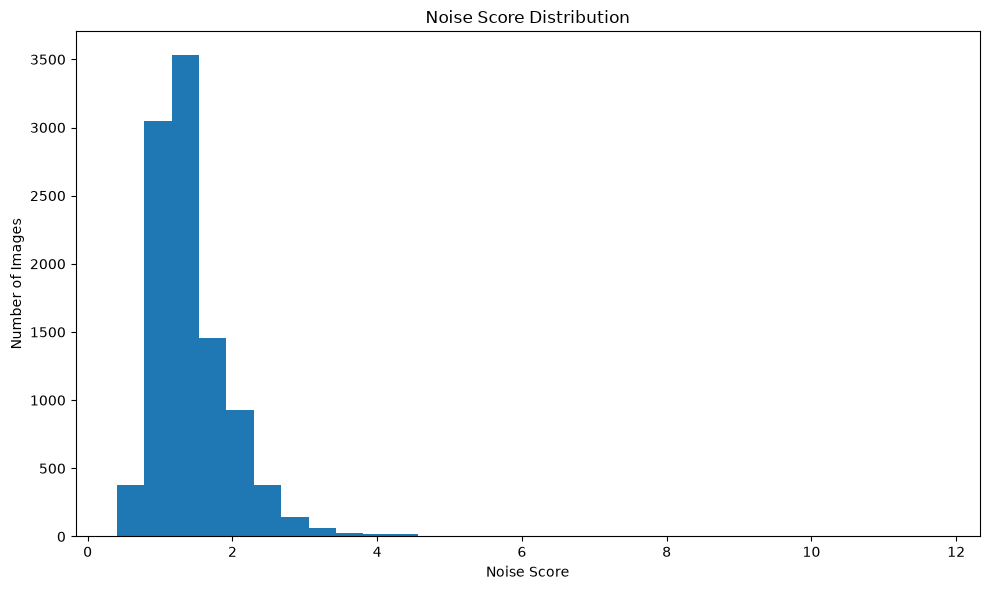

In [66]:
# Noise distribution

plt.figure(figsize=(10, 6))

plt.hist(metadata["noise_score"], bins=30)

plt.title("Noise Score Distribution")
plt.xlabel("Noise Score")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

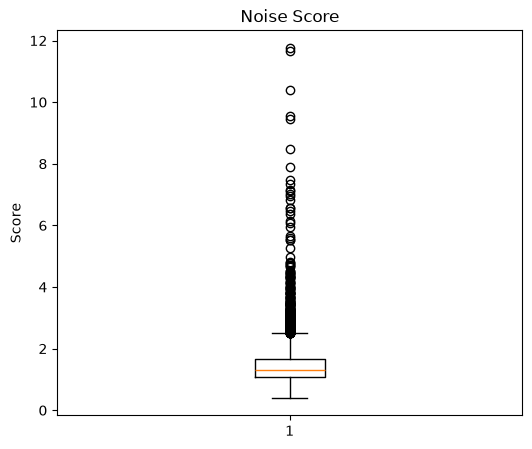

In [67]:
# Noise box plot

plt.figure(figsize=(6, 5))

plt.boxplot(metadata["noise_score"])

plt.title("Noise Score")
plt.ylabel("Score")

plt.show()

In [68]:
# Most noisy images

most_noisy = metadata.nlargest(5, "noise_score")

most_noisy[["image_id", "dx", "noise_score"]]

,image_id,dx,noise_score
7908,ISIC_0033786,nv,11.760930
3916,ISIC_0029330,nv,11.658637
3239,ISIC_0030128,nv,10.381000
2037,ISIC_0028228,mel,9.546437
6381,ISIC_0027123,nv,9.441489


In [69]:
# Cleanest images

cleanest = metadata.nsmallest(5, "noise_score")

cleanest[["image_id", "dx", "noise_score"]]

,image_id,dx,noise_score
4327,ISIC_0027325,nv,0.401504
8038,ISIC_0032510,nv,0.406730
5228,ISIC_0030471,nv,0.442356
610,ISIC_0026335,bkl,0.446952
6648,ISIC_0026031,nv,0.453489


In [70]:
# Save noise scores

metadata.to_csv(
    OUTPUT_DIR / "noise_scores.csv",
    index=False
)

print("Noise scores saved successfully.")

Noise scores saved successfully.


# Section 8: Diagnostic Hair Density Estimation

## Introduction

---

Hair artifacts are one of the most common quality issues in dermoscopic images. Dense hair occlusion can hide lesion boundaries, distort texture patterns, and reduce classification performance. Estimating hair density enables objective assessment of image quality prior to enhancement.

## Objectives

---

- Estimate the amount of hair present in every image.
- Generate a hair density score.
- Analyze hair density distribution.
- Identify images with high and low hair occlusion.
- Store hair density scores for Composite Quality Index (CQI) computation.

## Expected Output

---

- Hair density score for every image.
- Statistical summary of hair density.
- Hair density distribution.
- Identification of images with severe hair artifacts.
- Hair density score added to the metadata.

In [71]:
# Calculate hair density

def calculate_hair_density(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    blackhat = cv2.morphologyEx(
        gray,
        cv2.MORPH_BLACKHAT,
        cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    )

    _, hair_mask = cv2.threshold(
        blackhat,
        15,
        255,
        cv2.THRESH_BINARY
    )

    hair_density = np.sum(hair_mask > 0) / hair_mask.size

    return hair_density

In [72]:
# Calculate hair density

hair_density_scores = []

for image_path in tqdm(image_files):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    score = calculate_hair_density(image)

    hair_density_scores.append(score)

100%|██████████| 10015/10015 [00:40<00:00, 244.28it/s]


In [73]:
# Add hair density scores

metadata["hair_density"] = hair_density_scores

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,contrast_score,brightness_score,blur_score,noise_score,hair_density
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,31.016334,146.754770,43.876503,1.267311,0.027074
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,18.567454,152.554907,53.289048,1.324419,0.028237
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,49.687620,153.042381,85.947015,1.826748,0.138885
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,23.000077,134.099256,30.222626,1.090463,0.015211
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,31.513469,153.591919,156.135217,2.232430,0.251548


In [74]:
# Hair density statistics

print("=" * 60)
print("HAIR DENSITY STATISTICS")
print("=" * 60)

print(metadata["hair_density"].describe())

HAIR DENSITY STATISTICS
count    10015.000000
mean         0.069261
std          0.070620
min          0.000300
25%          0.021552
50%          0.045730
75%          0.093667
max          0.792093
Name: hair_density, dtype: float64


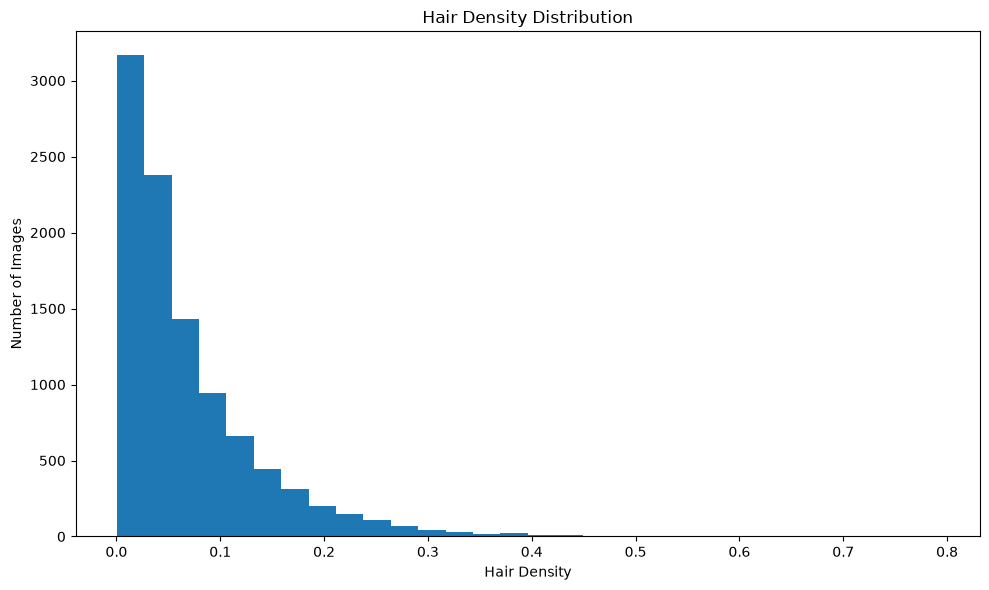

In [75]:
# Hair density distribution

plt.figure(figsize=(10,6))

plt.hist(metadata["hair_density"], bins=30)

plt.title("Hair Density Distribution")
plt.xlabel("Hair Density")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

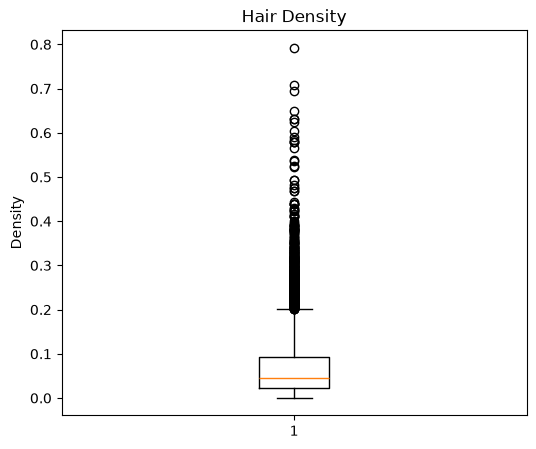

In [76]:
# Hair density box plot

plt.figure(figsize=(6,5))

plt.boxplot(metadata["hair_density"])

plt.title("Hair Density")

plt.ylabel("Density")

plt.show()

In [77]:
# Highest hair density images

highest_hair = metadata.nlargest(5, "hair_density")

highest_hair[
    ["image_id", "dx", "hair_density"]
]

,image_id,dx,hair_density
7908,ISIC_0033786,nv,0.792093
3916,ISIC_0029330,nv,0.708341
2037,ISIC_0028228,mel,0.694133
1575,ISIC_0033068,mel,0.649967
6140,ISIC_0031760,nv,0.630507


In [78]:
# Lowest hair density images

lowest_hair = metadata.nsmallest(5, "hair_density")

lowest_hair[
    ["image_id", "dx", "hair_density"]
]

,image_id,dx,hair_density
2786,ISIC_0029655,bcc,0.000300
6362,ISIC_0025399,nv,0.000344
8605,ISIC_0031363,nv,0.000596
6881,ISIC_0025108,nv,0.000737
4792,ISIC_0027028,nv,0.000752


In [79]:
# Save hair density scores

metadata.to_csv(
    OUTPUT_DIR / "hair_density_scores.csv",
    index=False
)

print("Hair density scores saved successfully.")

Hair density scores saved successfully.


# Section 9: Composite Quality Index (CQI)

## Introduction

---

The Composite Quality Index (CQI) combines multiple diagnostic image quality metrics into a single quantitative score. The CQI provides an overall assessment of image quality by integrating contrast, brightness, blur, noise, and hair density measurements. This quality score can be used to identify low-quality images and guide adaptive preprocessing before deep learning-based classification.

## Objectives

---

- Normalize all quality metrics.
- Compute the Composite Quality Index (CQI).
- Categorize images based on quality.
- Analyze the CQI distribution.
- Prepare the dataset for adaptive image enhancement.

## Expected Output

---

- Normalized quality metrics.
- CQI score for every image.
- Image quality categories.
- CQI statistical summary.
- CQI distribution visualization.

In [80]:
# Import scaler

from sklearn.preprocessing import MinMaxScaler

In [81]:
# Normalize quality metrics

scaler = MinMaxScaler()

metadata["contrast_norm"] = scaler.fit_transform(
    metadata[["contrast_score"]]
)

metadata["brightness_norm"] = scaler.fit_transform(
    metadata[["brightness_score"]]
)

metadata["blur_norm"] = scaler.fit_transform(
    metadata[["blur_score"]]
)

metadata["noise_norm"] = 1 - scaler.fit_transform(
    metadata[["noise_score"]]
)

metadata["hair_norm"] = 1 - scaler.fit_transform(
    metadata[["hair_density"]]
)

In [82]:
# Compute Composite Quality Index

metadata["CQI"] = (
    0.25 * metadata["contrast_norm"] +
    0.20 * metadata["brightness_norm"] +
    0.25 * metadata["blur_norm"] +
    0.15 * metadata["noise_norm"] +
    0.15 * metadata["hair_norm"]
)

In [83]:
# CQI statistics

print("=" * 60)
print("COMPOSITE QUALITY INDEX")
print("=" * 60)

print(metadata["CQI"].describe())

COMPOSITE QUALITY INDEX
count    10015.000000
mean         0.463474
std          0.040199
min          0.310102
25%          0.436476
50%          0.460438
75%          0.486457
max          0.690947
Name: CQI, dtype: float64


In [84]:
# Image quality classification

def classify_quality(score):

    if score >= 0.80:
        return "Excellent"

    elif score >= 0.60:
        return "Good"

    elif score >= 0.40:
        return "Fair"

    else:
        return "Poor"


metadata["quality_label"] = metadata["CQI"].apply(classify_quality)

In [85]:
# Quality distribution

quality_distribution = metadata["quality_label"].value_counts()

print("=" * 60)
print("QUALITY DISTRIBUTION")
print("=" * 60)

print(quality_distribution)

QUALITY DISTRIBUTION
quality_label
Fair    9574
Poor     401
Good      40
Name: count, dtype: int64


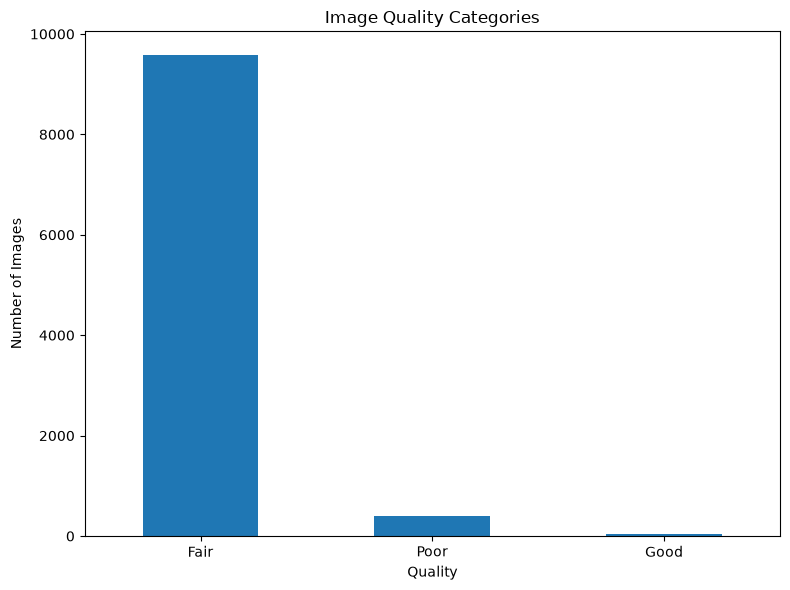

In [86]:
# Quality distribution plot

plt.figure(figsize=(8,6))

quality_distribution.plot(kind="bar")

plt.title("Image Quality Categories")

plt.xlabel("Quality")

plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

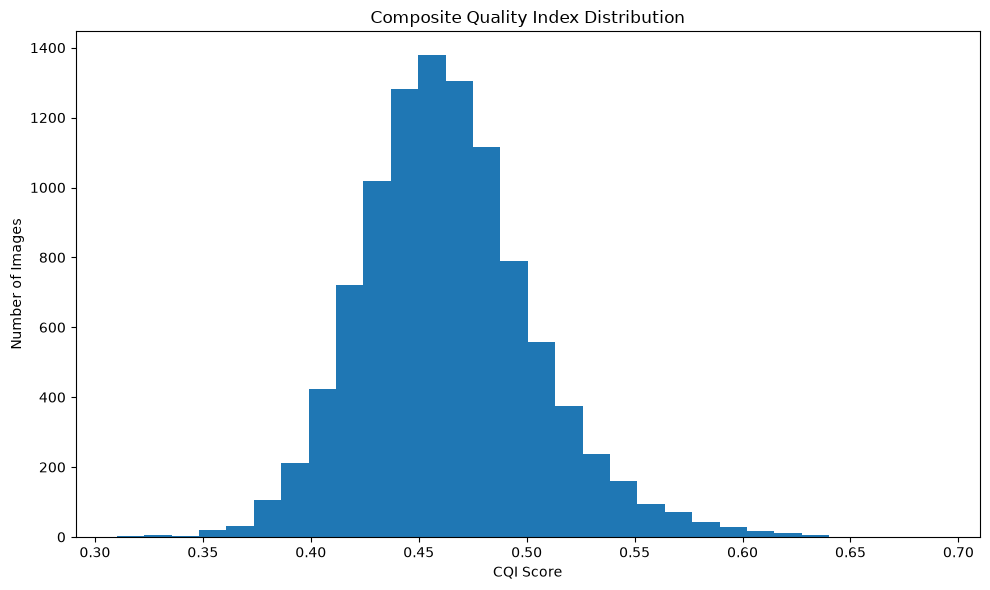

In [87]:
# CQI distribution

plt.figure(figsize=(10,6))

plt.hist(metadata["CQI"], bins=30)

plt.title("Composite Quality Index Distribution")

plt.xlabel("CQI Score")

plt.ylabel("Number of Images")

plt.tight_layout()

plt.show()

In [88]:
# Highest quality images

metadata.nlargest(
    5,
    "CQI"
)[
    [
        "image_id",
        "dx",
        "CQI",
        "quality_label"
    ]
]

,image_id,dx,CQI,quality_label
6717,ISIC_0029845,nv,0.690947,Good
1795,ISIC_0029606,mel,0.651562,Good
9356,ISIC_0025670,nv,0.639268,Good
4721,ISIC_0024735,nv,0.632663,Good
3780,ISIC_0031544,nv,0.628866,Good


In [89]:
# Lowest quality images

metadata.nsmallest(
    5,
    "CQI"
)[
    [
        "image_id",
        "dx",
        "CQI",
        "quality_label"
    ]
]

,image_id,dx,CQI,quality_label
4515,ISIC_0029874,nv,0.310102,Poor
4288,ISIC_0030154,nv,0.311831,Poor
1575,ISIC_0033068,mel,0.324709,Poor
7189,ISIC_0032874,nv,0.325430,Poor
1736,ISIC_0025531,mel,0.327145,Poor


In [90]:
# Save CQI dataset

metadata.to_csv(
    OUTPUT_DIR / "ham10000_cqi_dataset.csv",
    index=False
)

print("CQI dataset saved successfully.")

CQI dataset saved successfully.


In [91]:
# Preview final dataset

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,contrast_score,brightness_score,blur_score,noise_score,hair_density,contrast_norm,brightness_norm,blur_norm,noise_norm,hair_norm,CQI,quality_label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,31.016334,146.754770,43.876503,1.267311,0.027074,0.321047,0.515732,0.009497,0.923781,0.966185,0.469277,Fair
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,18.567454,152.554907,53.289048,1.324419,0.028237,0.165878,0.549520,0.011962,0.918753,0.964717,0.436885,Fair
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,49.687620,153.042381,85.947015,1.826748,0.138885,0.553776,0.552359,0.020517,0.874532,0.824973,0.508971,Fair
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,23.000077,134.099256,30.222626,1.090463,0.015211,0.221129,0.442009,0.005920,0.939349,0.981168,0.433242,Fair
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,31.513469,153.591919,156.135217,2.232430,0.251548,0.327244,0.555560,0.038904,0.838819,0.682684,0.430875,Fair


# Section 10: Save Reports & Export Results

## Introduction

---

The final stage of the quality assessment pipeline exports the Composite Quality Index (CQI), quality metrics, summary statistics, and visualizations. These outputs serve as the foundation for the adaptive preprocessing pipeline and subsequent deep learning model training.

## Objectives

---

- Export the final metadata with all quality metrics.
- Save summary statistics.
- Save quality distribution reports.
- Export all visualizations.
- Prepare the dataset for the next preprocessing stage.

## Expected Output

---

- Final quality assessment dataset.
- Summary statistics report.
- Quality distribution report.
- Publication-ready figures.
- Dataset ready for adaptive preprocessing.

In [92]:
# Create report directory

REPORT_DIR = OUTPUT_DIR / "reports"

REPORT_DIR.mkdir(exist_ok=True)

In [93]:
# Save final metadata

metadata.to_csv(
    REPORT_DIR / "HAM10000_Quality_Assessment.csv",
    index=False
)

print("Final metadata saved successfully.")

Final metadata saved successfully.


In [94]:
# Save summary statistics

summary_statistics = metadata.describe(include="all")

summary_statistics.to_csv(
    REPORT_DIR / "Summary_Statistics.csv"
)

print("Summary statistics saved successfully.")

Summary statistics saved successfully.


In [95]:
# Save quality distribution

quality_distribution.to_csv(
    REPORT_DIR / "Quality_Distribution.csv"
)

print("Quality distribution saved successfully.")

Quality distribution saved successfully.


In [96]:
# Save CQI statistics

cqi_statistics = metadata["CQI"].describe()

cqi_statistics.to_csv(
    REPORT_DIR / "CQI_Statistics.csv"
)

print("CQI statistics saved successfully.")

CQI statistics saved successfully.


In [97]:
# Save quality label counts

metadata["quality_label"].value_counts().to_csv(
    REPORT_DIR / "Quality_Label_Counts.csv"
)

print("Quality labels saved successfully.")

Quality labels saved successfully.


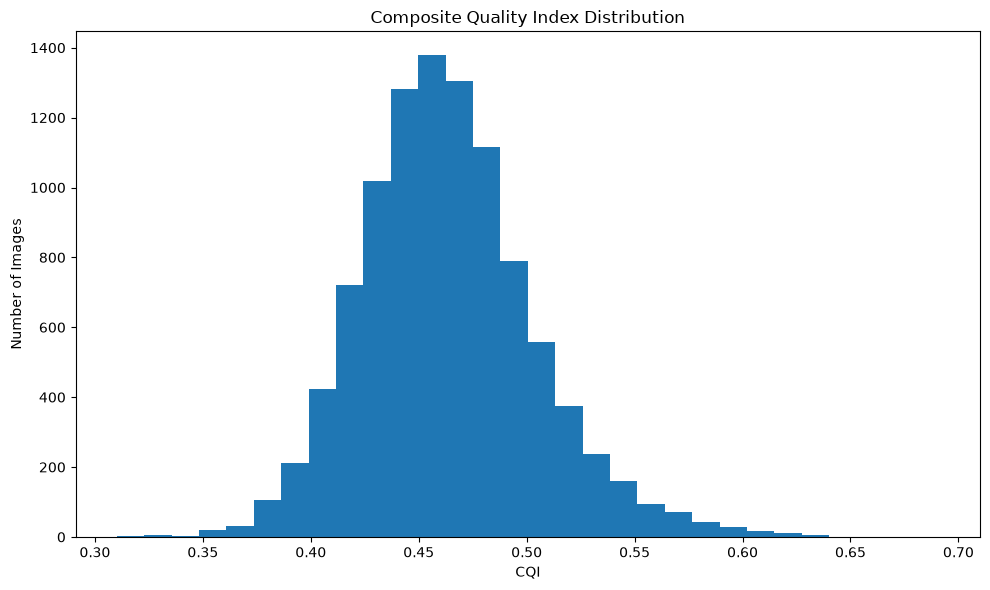

In [98]:
# Save CQI distribution figure

plt.figure(figsize=(10,6))

plt.hist(metadata["CQI"], bins=30)

plt.title("Composite Quality Index Distribution")
plt.xlabel("CQI")
plt.ylabel("Number of Images")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "CQI_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

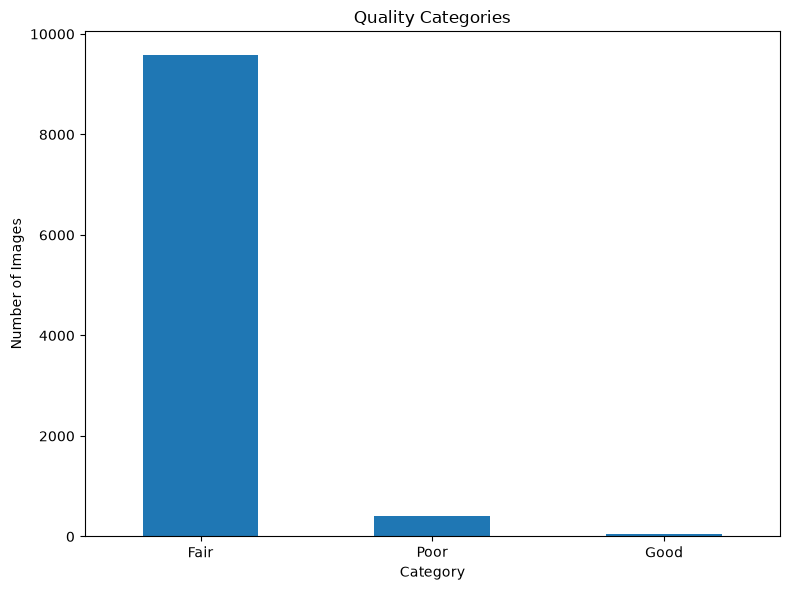

In [99]:
# Save quality category figure

plt.figure(figsize=(8,6))

quality_distribution.plot(kind="bar")

plt.title("Quality Categories")

plt.xlabel("Category")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "Quality_Categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
# Display final dataset

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,contrast_score,brightness_score,blur_score,noise_score,hair_density,contrast_norm,brightness_norm,blur_norm,noise_norm,hair_norm,CQI,quality_label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,31.016334,146.754770,43.876503,1.267311,0.027074,0.321047,0.515732,0.009497,0.923781,0.966185,0.469277,Fair
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,18.567454,152.554907,53.289048,1.324419,0.028237,0.165878,0.549520,0.011962,0.918753,0.964717,0.436885,Fair
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,49.687620,153.042381,85.947015,1.826748,0.138885,0.553776,0.552359,0.020517,0.874532,0.824973,0.508971,Fair
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,23.000077,134.099256,30.222626,1.090463,0.015211,0.221129,0.442009,0.005920,0.939349,0.981168,0.433242,Fair
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,31.513469,153.591919,156.135217,2.232430,0.251548,0.327244,0.555560,0.038904,0.838819,0.682684,0.430875,Fair


In [101]:
# Pipeline summary

print("=" * 70)
print("HAM10000 DIAGNOSTIC QUALITY ASSESSMENT COMPLETED")
print("=" * 70)

print(f"Total Images               : {len(metadata):,}")
print(f"Contrast Scores            : ✓")
print(f"Brightness Scores          : ✓")
print(f"Blur Scores                : ✓")
print(f"Noise Scores               : ✓")
print(f"Hair Density Scores        : ✓")
print(f"Composite Quality Index    : ✓")
print(f"Quality Classification     : ✓")

print("\nOutputs Saved To")
print(REPORT_DIR)

print("\nNotebook 01 Completed Successfully.")

HAM10000 DIAGNOSTIC QUALITY ASSESSMENT COMPLETED
Total Images               : 10,015
Contrast Scores            : ✓
Brightness Scores          : ✓
Blur Scores                : ✓
Noise Scores               : ✓
Hair Density Scores        : ✓
Composite Quality Index    : ✓
Quality Classification     : ✓

Outputs Saved To
D:\Projects\DermaCQI\outputs\reports

Notebook 01 Completed Successfully.
